# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [119]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_directory = "output/prototype_pipeline_subset_stage2/"


In [ ]:
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs, load_cloccs_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

cold_start = False
chrom = 4
replicate = 1
num_epochs = 10
config = None
config, _ = load_cloccs_configs(shift_CLOCCS=False)

np.random.seed(123)

update_params_df, replication_deconvolver, optimizer = fit_replication_profile(chrom=chrom, 
    replicate=replicate, num_epochs=num_epochs, output_directory=output_directory, 
    save=False, config=config,
    learn_subset_parameters=['mu0', 'sigma0', 'gamma2'])


Loading MNase data


In [148]:
replication_deconvolver.config.params_dic

{'mu0': -23.42392137233829,
 'delta': 8.1805,
 'sigma0': 4.598775855923117,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.0041,
 'gamma2': 0.3783544359674006,
 'halted': 0.2245,
 'alpha': 22}

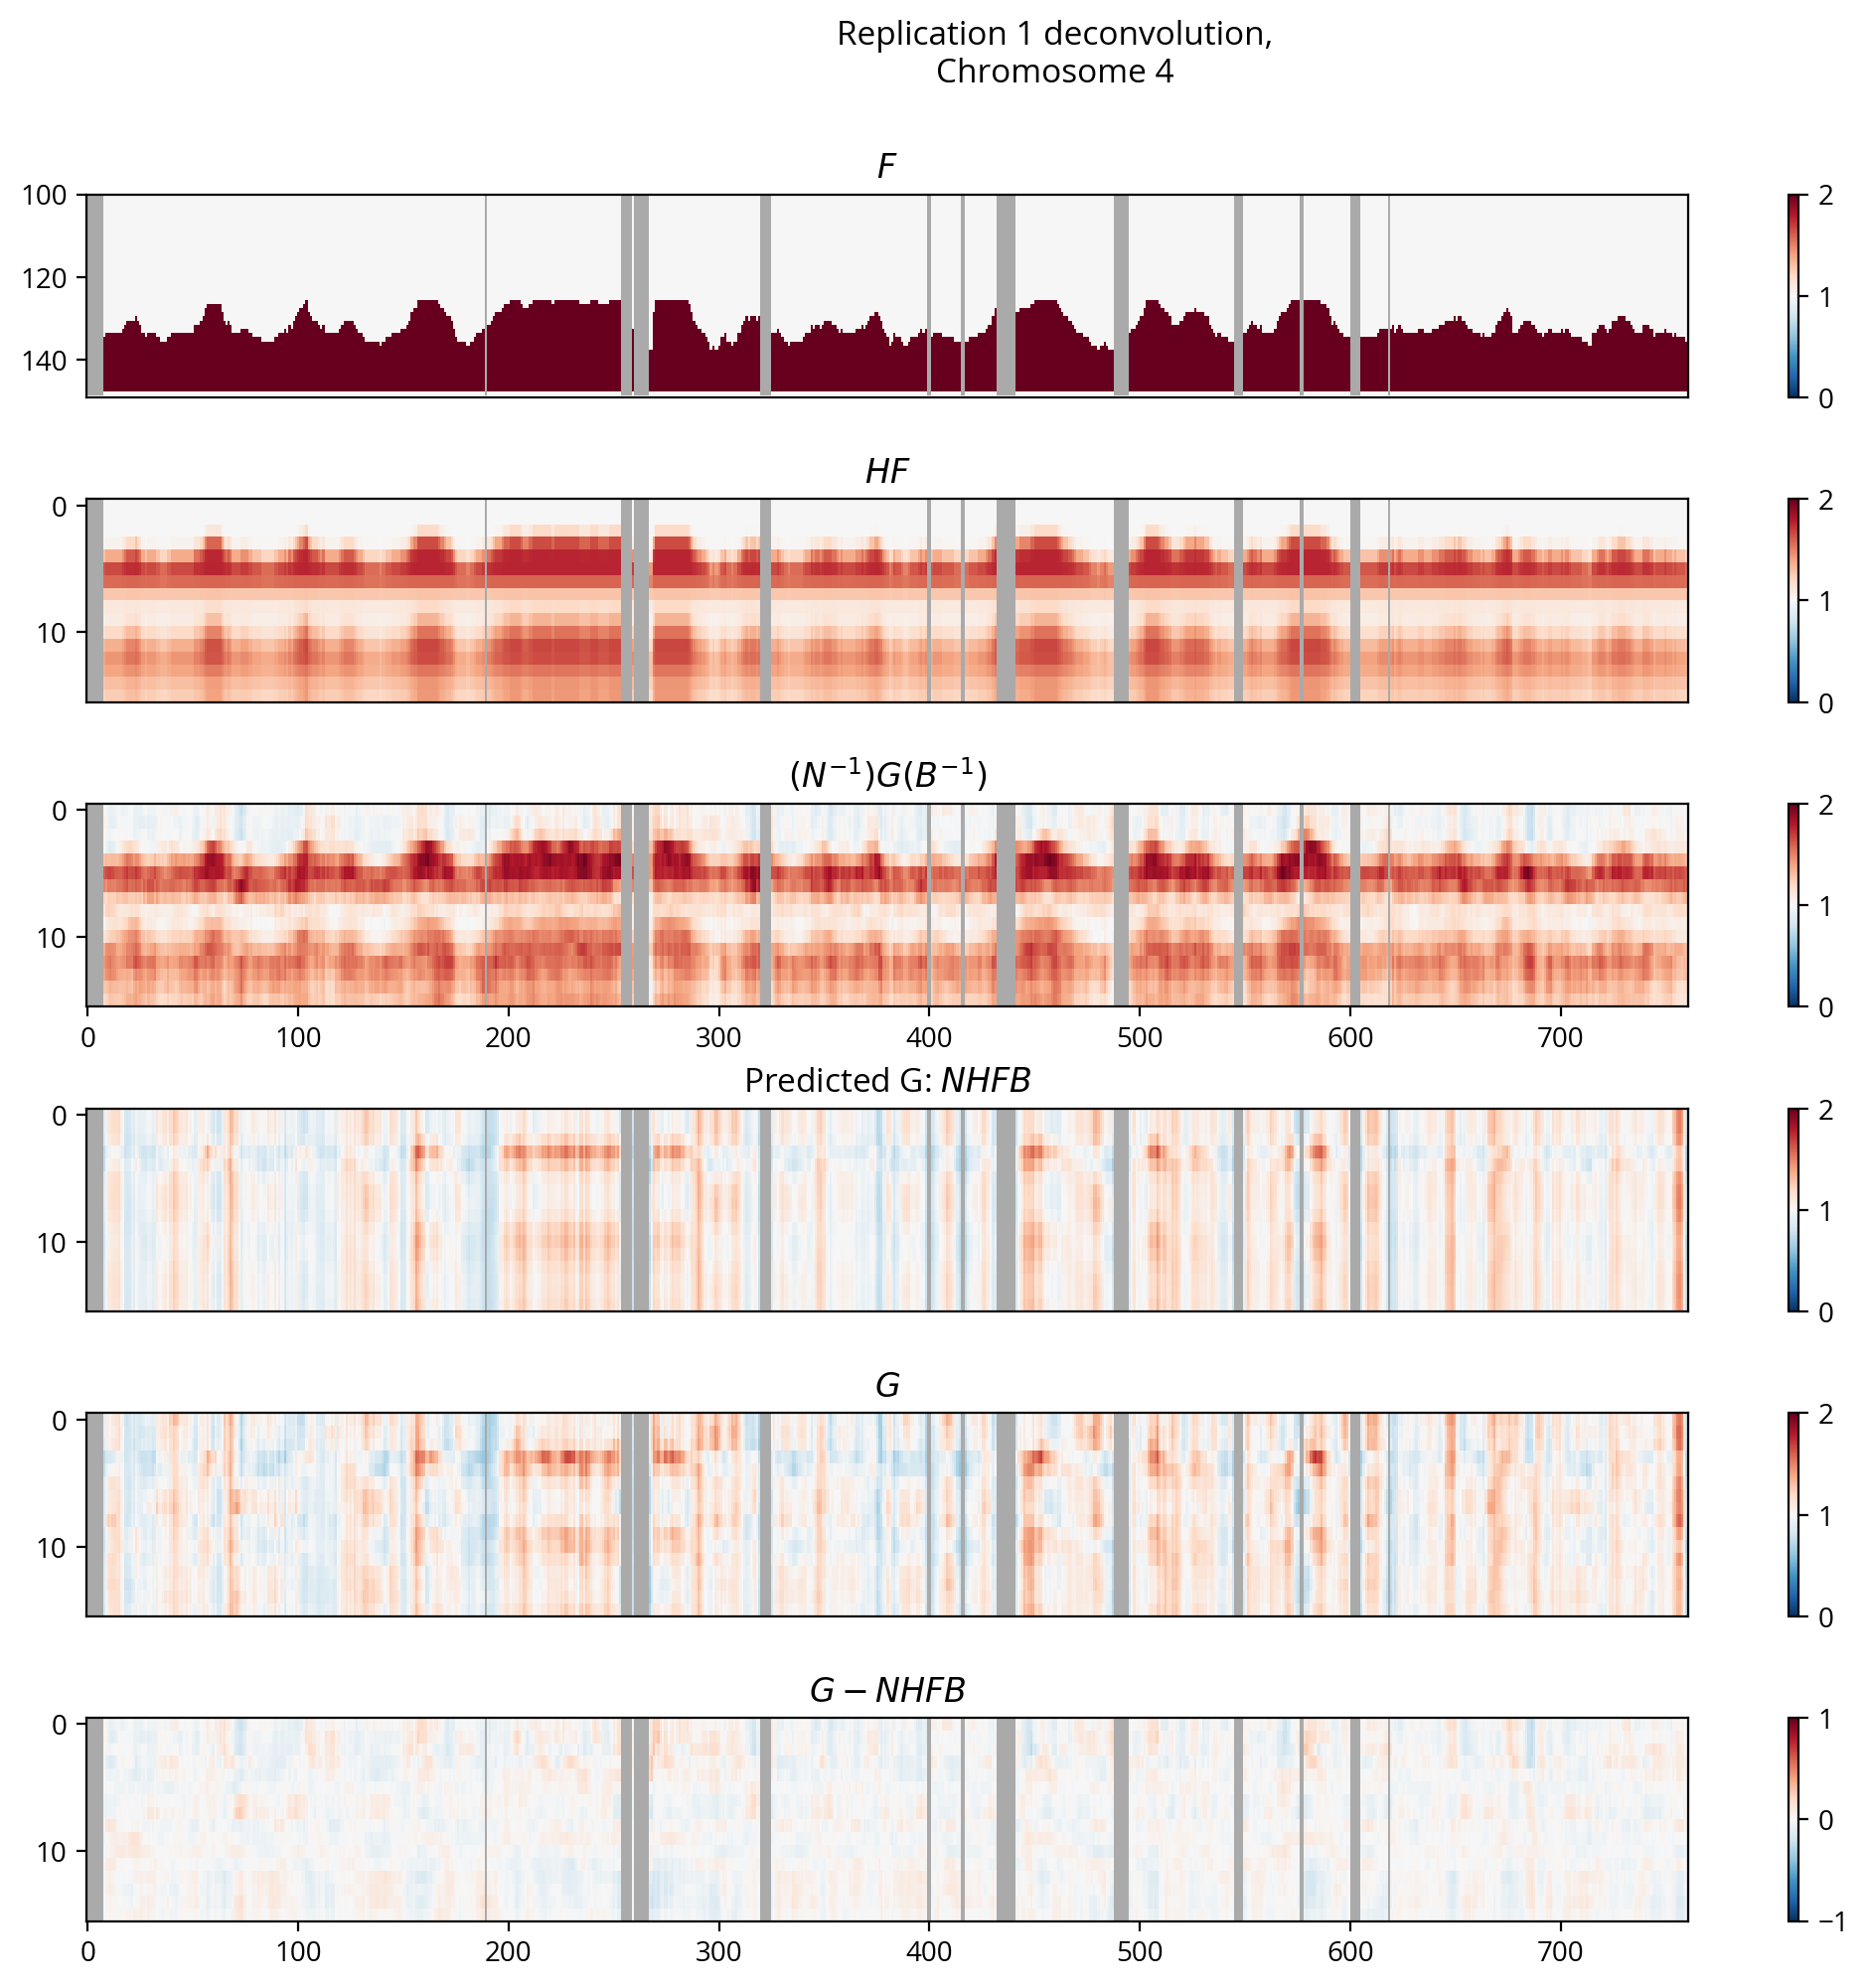

In [149]:
fig = replication_deconvolver.plot_heatmaps()